# Week 2 — interpretable feature EDA

**Exploration only — not on the reproducibility path.** Load-bearing numbers live in `scripts/analysis/*.py` and `build-log.md` (see `notebooks/README.md`).

Inputs: `data/features_sample.parquet` (from `scripts/extract_features.py` over the 50-cover seed-42 sample).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # run from repo root or notebooks/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../data/features_sample.parquet')
FEATURES = [
    'sal_gini', 'sal_top10_mass', 'text_block_count', 'n_text_boxes_full',
    'legib_box_retention', 'legib_char_retention', 'title_contrast_ratio',
    'median_text_contrast_ratio', 'feature_congestion', 'subband_entropy',
]
df[FEATURES].describe(percentiles=[.1, .5, .9]).T.round(3)

,count,mean,std,min,10%,50%,90%,max
sal_gini,50.0,0.615,0.103,0.434,0.508,0.605,0.741,0.856
sal_top10_mass,50.0,0.428,0.126,0.267,0.306,0.397,0.644,0.797
text_block_count,50.0,1.740,1.084,0.000,1.000,2.000,3.000,6.000
n_text_boxes_full,50.0,6.160,2.979,2.000,3.000,6.000,10.100,17.000
legib_box_retention,50.0,0.485,0.287,0.000,0.123,0.500,1.000,1.000
legib_char_retention,46.0,0.312,0.306,0.000,0.000,0.243,0.753,1.000
title_contrast_ratio,46.0,5.659,2.552,2.088,2.758,5.089,9.454,11.500
median_text_contrast_ratio,46.0,5.521,2.166,2.356,3.076,4.891,8.767,11.500
feature_congestion,50.0,4.877,1.626,1.909,2.835,4.713,7.036,8.534
subband_entropy,50.0,2.935,0.483,1.704,2.403,2.917,3.449,3.756


## Distributions

Looking for: degenerate columns (all one value), and whether the spread is wide enough to carry signal at n≈52k.

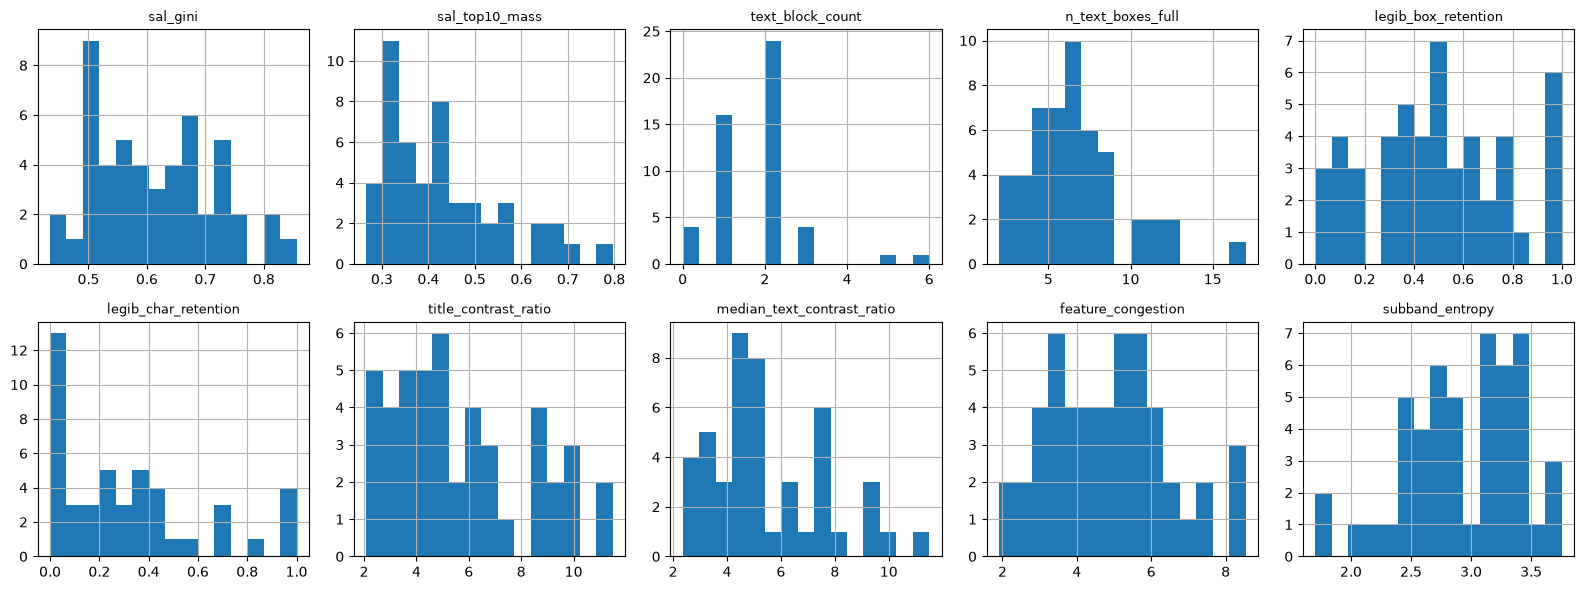

In [2]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.ravel(), FEATURES):
    df[col].hist(ax=ax, bins=15)
    ax.set_title(col, fontsize=9)
fig.tight_layout()

## Collinearity (hand this to the Nov modeling)

Model C is a nested comparison against Model A — heavily collinear cover features will make its
coefficients uninterpretable. Flag pairs with |spearman| > 0.6. **n=50 here**, recompute on the
full run before deciding what to drop.

|spearman| > 0.6:
  sal_gini                   sal_top10_mass             +0.94
  sal_gini                   subband_entropy            -0.82
  sal_top10_mass             subband_entropy            -0.77
  median_text_contrast_ratio title_contrast_ratio       +0.86
  feature_congestion         sal_gini                   -0.77
  feature_congestion         sal_top10_mass             -0.77
  feature_congestion         subband_entropy            +0.70


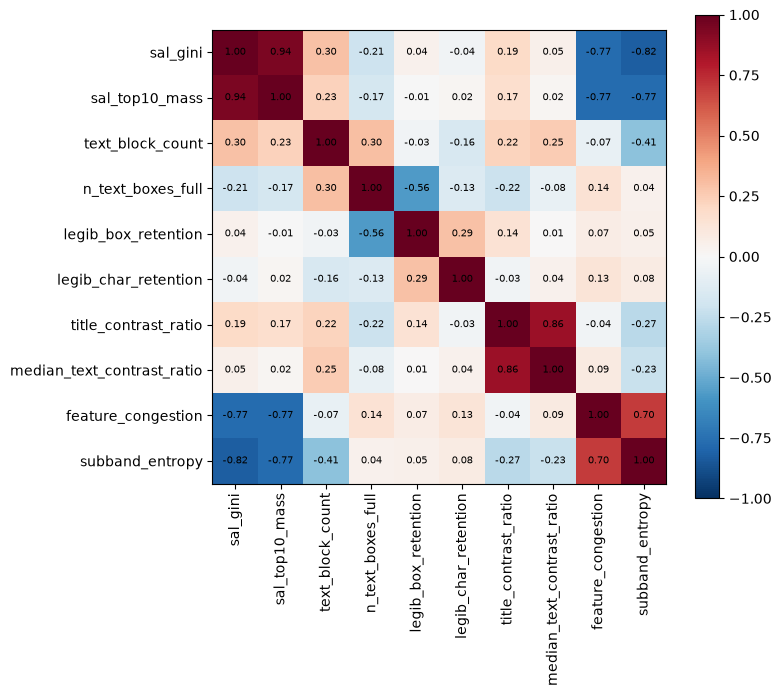

In [3]:
corr = df[FEATURES].corr('spearman')
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(FEATURES))); ax.set_xticklabels(FEATURES, rotation=90)
ax.set_yticks(range(len(FEATURES))); ax.set_yticklabels(FEATURES)
for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
fig.colorbar(im); fig.tight_layout()

print('|spearman| > 0.6:')
for a in FEATURES:
    for b in FEATURES:
        if a < b and abs(corr.loc[a, b]) > 0.6:
            print(f'  {a:26s} {b:26s} {corr.loc[a, b]:+.2f}')

## Why the saliency set has 2 columns, not 3

`sal_norm_entropy` was dropped: spearman −1.0 with `sal_gini`. Reproduced by
`scripts/analysis/saliency_redundancy.py`.

In [4]:
from scripts.analysis.saliency_redundancy import main as saliency_redundancy
saliency_redundancy()

n = 0 sample covers

  spearman(sal_gini, sal_norm_entropy) = +nan   <- reason entropy was dropped
  pearson (sal_gini, sal_norm_entropy) = +nan
  spearman(sal_gini, sal_top10_mass)   = +nan   <- 0.94, kept: not a restatement

  interpretation: after smoothing + [0,1] normalization the saliency maps vary along
  essentially one axis (peaky vs flat), so every concentration statistic ranks the
  covers identically. gini + top10 mass are kept; entropy adds nothing.


/Users/patrickcher/Library/CloudStorage/GoogleDrive-patrickcher@gmail.com/My Drive/AI Thoughts/2026-10-book-cover-design-guidelines/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:587: RuntimeWarning: Mean of empty slice
  avg = a.mean(axis, **keepdims_kw)
/Users/patrickcher/Library/CloudStorage/GoogleDrive-patrickcher@gmail.com/My Drive/AI Thoughts/2026-10-book-cover-design-guidelines/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:134: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/Users/patrickcher/Library/CloudStorage/GoogleDrive-patrickcher@gmail.com/My Drive/AI Thoughts/2026-10-book-cover-design-guidelines/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3028: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/Users/patrickcher/Library/CloudStorage/GoogleDrive-patrickcher@gmail.com/My Drive/AI Thoughts/2026-10-book-cover-design-guidelines/.venv/lib/python3.12/site-

## Thumbnail legibility: v1 (replaced) vs v2 (current)

v1 = recognized-char retention, v2 = detector-box retention. v1 was measuring EasyOCR's
recognizer floor — many exact zeros, ~0 correlation with contrast. Full A/B in
`scripts/analysis/thumbnail_legibility_ab.py`; quick visual here.

v1 exact zeros: 12  v2 exact zeros: 3


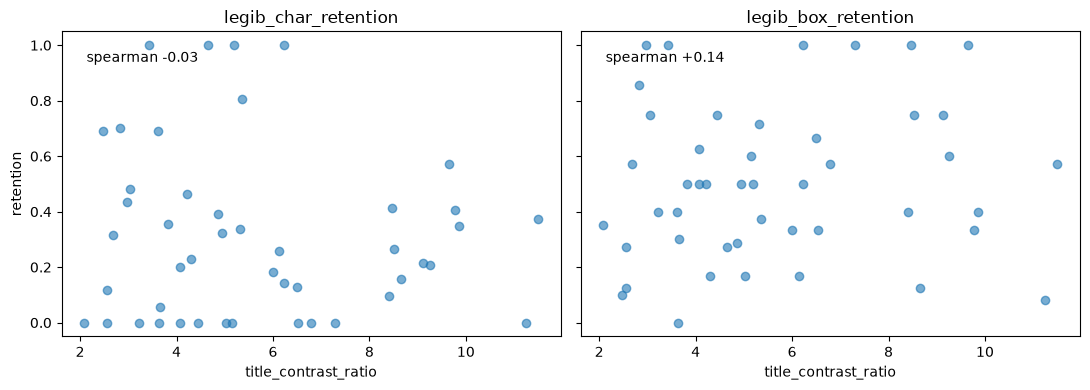

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, col in zip(axes, ['legib_char_retention', 'legib_box_retention']):
    ax.scatter(df['title_contrast_ratio'], df[col], alpha=0.6)
    ax.set_xlabel('title_contrast_ratio'); ax.set_title(col)
    sub = df[['title_contrast_ratio', col]].dropna()
    r = sub.corr('spearman').iloc[0, 1]
    ax.text(0.05, 0.9, f'spearman {r:+.2f}', transform=ax.transAxes)
axes[0].set_ylabel('retention'); fig.tight_layout()
print('v1 exact zeros:', int((df['legib_char_retention'] == 0).sum()),
      ' v2 exact zeros:', int((df['legib_box_retention'] == 0).sum()))

## Contact sheet

`scripts/smoke_features_report.py` writes `data/sample_features_contactsheet.png` — covers sorted
by Feature Congestion with features overlaid, for eyeballing whether the numbers match the art.